# Overview

We're now switching focus away from the Network Science (for a little bit), beginning to think about _Natural Language Processing_ instead. Remember that the overall point of the course is to analyze networks where you have access to information (in this case text) about each node. In this class we keep it old-school and stay away from transformers, LSTMs, etc. 

It is my goal to show you just how far one can get with good old fashioned statistics for understanding text.

In other words, today will be all about the very first steps in teaching your computer to "understand" text. This ties in nicely with our work on wikipedia, since wikipedia is a network of connected pieces of text. We've looked at the network so far - now, let's see if we can include the text. Today is about 

* Installing the _natural language toolkit_ (NLTK) package and learning the basics of how it works (Chapter 1)
* Figuring out how to make NLTK to work with other types of text (Chapter 2).

I know that last week as a little bit intense in terms of workload, so I've made today an easy one. 

# Part 1: A little lecture

> **_Video Lecture_**. Today is all about ***working*** with NLTK, so not much lecturing - you can get my perspective and a little pep-talk

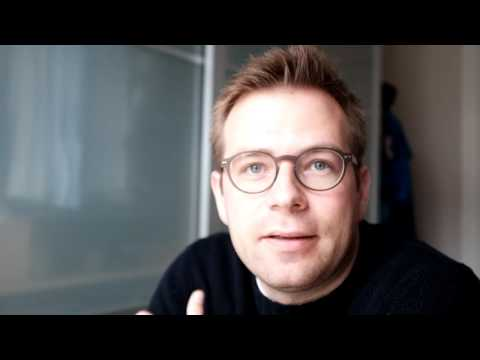

In [30]:
from IPython.display import YouTubeVideo
YouTubeVideo("Ph0EHmFT3n4",width=800, height=450)

# Part 2: Installing and the basics

> _Reading_
> The reading for today is Natural Language Processing with Python (NLPP) Chapter 1, Sections 1.1, 1.2, 1.3\. [It's free online](http://www.nltk.org/book/). 


> *Exercises*: NLPP Chapter 1\.
> 
> * First, install `nltk` if it isn't installed already (there are some tips below that I recommend checking out before doing installing)
> * Second, **work through** chapter 1. The book is set up as a kind of tutorial with lots of examples for you to work through. I recommend you read the text with an open Jupyter Notebook and type out the examples that you see. ***It becomes much more fun if you to add a few variations and see what happens***. Some of those examples might very well be due as assignments (see below the install tips), so those ones should definitely be in a `notebook`. 
 

### NLTK Install tips 

Check to see if `nltk` is installed on your system by typing `import nltk` in a `notebook`. If it's not already installed, install it as part of _Anaconda_ by typing 

     conda install nltk 

at the command prompt. If you don't have them, you can download the various corpora, tokenizers, the collection of books, etc by typing `nltk.download("book")`. The output will tell you where NLTK is storing the data in your system. The total download size is about 371mb.

In [31]:
import nltk
from nltk.book import *
import numpy as np
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder
from nltk.corpus import stopwords
import tkinter
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

> *Exercises: From NLPP Chapter 1.
> 
> The following exercises from Chapter 1 are what might be due in an assignment later on.
>
> * Try out the `concordance` method, using another text and a word of your own choosing.
> * Also try out the `similar` and `common_context` methods for a few of your own examples.
> * Create your own version of a dispersion plot ("your own version" means another text and different word).
> * Explain in your own words what aspect of language _lexical diversity_ describes. 
> * Create frequency distributions for `text2`, including the cumulative frequency plot for the 75 most common words.
> * What is a bigram? How does it relate to `collocations`. Explain in your own words.
> * Work through ex 2-12 in NLPP's section 1.8\. 
> * Work through exercise 15, 17, 19, 22, 23, 26, 27, 28 in section 1.8\.

<div class="alert alert-block alert-info">
Don't use an LLM for these ones. See if you can solve them yourself. Remember that this is about learning how the NLTK package works, not about just getting to the various results.
</div>

> * Try out the `concordance` method, using another text and a word of your own choosing.
> * Also try out the `similar` and `common_context` methods for a few of your own examples.
> * Create your own version of a dispersion plot ("your own version" means another text and different word).

Concordance for 'love' in text3 (The Book of Genesis):
Displaying 4 of 4 matches:
And make me savoury meat , such as I love , and bring it to me , that I may ea
ury meat for thy father , such as he love And thou shalt bring it to thy fathe
ed unto him but a few days , for the love he had to her . And Jacob said unto 
tion ; now therefore my husband will love me . And she conceived again , and b

Words similar to 'man' in text1 (Moby Dick):
whale ship one it thing boat time all that ahab him sea captain whales
way matter moment and world as

Common contexts for 'man' and 'woman' in text1:
old_s a_s old_he old_of

Dispersion plot for 'God', 'man', 'earth', 'heaven' in text3:


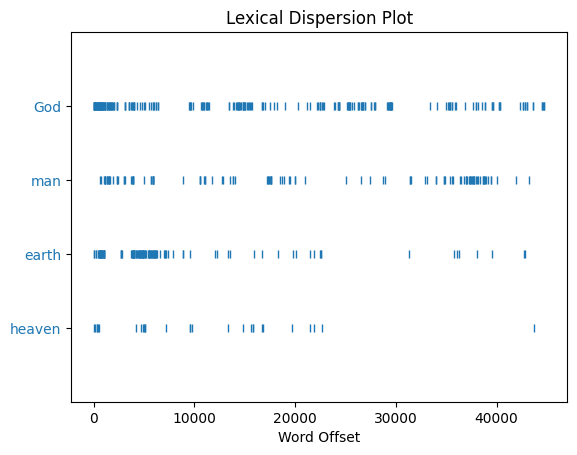

In [32]:
# 1. Try out the `concordance` method, using another text and a word of your own choosing.
print("Concordance for 'love' in text3 (The Book of Genesis):")
text3.concordance("love")

# 2. Try out the `similar` and `common_contexts` methods for a few of your own examples.
print("\nWords similar to 'man' in text1 (Moby Dick):")
text1.similar("man")

print("\nCommon contexts for 'man' and 'woman' in text1:")
text1.common_contexts(["man", "woman"])

# 3. Create your own version of a dispersion plot ("your own version" means another text and different word).
print("\nDispersion plot for 'God', 'man', 'earth', 'heaven' in text3:")
text3.dispersion_plot(["God", "man", "earth", "heaven"])

> ### - Explain in your own words what aspect of language _lexical diversity_ describes. 
> ### - Create frequency distributions for `text2`, including the cumulative frequency plot for the 75 most common words.
> ### - What is a bigram? How does it relate to `collocations`. Explain in your own words.


Lexical diversity describes the variety of unique words used in a text compared to the total number of words.
A higher lexical diversity means the text uses a wider range of vocabulary,
while a lower value indicates more repetition of the same words.

Most common 10 words in text2 (Sense and Sensibility):
[(',', 9397), ('to', 4063), ('.', 3975), ('the', 3861), ('of', 3565), ('and', 3350), ('her', 2436), ('a', 2043), ('I', 2004), ('in', 1904)]

Cumulative frequency plot for the 75 most common words in text2:

A bigram is a pair of consecutive words in a text. 
 Collocations are pairs of words that occur together more often than would be expected by chance, 
 and are often identified by looking at frequent bigrams.


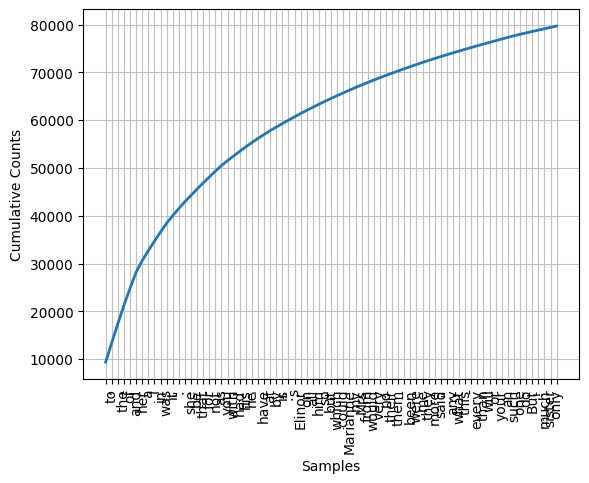

In [33]:

# 4. Explain in your own words what aspect of language _lexical diversity_ describes.
print("\nLexical diversity describes the variety of unique words used in a text compared to the total number of words.\nA higher lexical diversity means the text uses a wider range of vocabulary,\nwhile a lower value indicates more repetition of the same words.")

# 5. Create frequency distributions for `text2`, including the cumulative frequency plot for the 75 most common words.
fdist2 = FreqDist(text2)
print("\nMost common 10 words in text2 (Sense and Sensibility):")
print(fdist2.most_common(10))

print("\nCumulative frequency plot for the 75 most common words in text2:")
fdist2.plot(75, cumulative=True)

# 6. What is a bigram? How does it relate to `collocations`. Explain in your own words.
print("\nA bigram is a pair of consecutive words in a text. \n Collocations are pairs of words that occur together more often than would be expected by chance, \n and are often identified by looking at frequent bigrams.")


> ### - Work through ex 2-12 in NLPP's section 1.8\. 

2. Number of possible hundred-letter strings (26^100): 3142930641582938830174357788501626427282669988762475256374173175398995908420104023465432599069702289330964075081611719197835869803511992549376

3. ['Monty', 'Python'] * 3: ['Monty', 'Python', 'Monty', 'Python', 'Monty', 'Python']
3. 3 * sent1 (first 10 words of text1): ['[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', '1851', ']', 'ETYMOLOGY', '.', '[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', '1851', ']', 'ETYMOLOGY', '.', '[', 'Moby', 'Dick', 'by', 'Herman', 'Melville', '1851', ']', 'ETYMOLOGY', '.']

4. Number of words in text2: 141576
4. Number of distinct words in text2: 6833
Genres ranked by lexical diversity (highest to lowest):
humor          : 0.2313
science_fiction: 0.2234
reviews        : 0.2119
religion       : 0.1618
editorial      : 0.1605
hobbies        : 0.1449
news           : 0.1431
fiction        : 0.1358
lore           : 0.1315
adventure      : 0.1280
mystery        : 0.1221
romance        : 0.1207
government

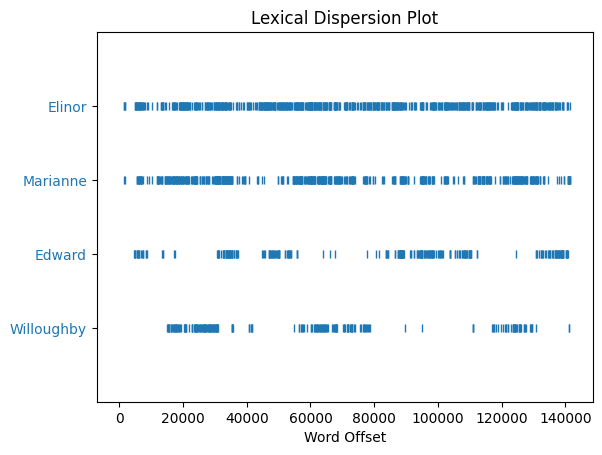

In [34]:

# 2. ☼ Given an alphabet of 26 letters, there are 26 to the power 10, or 26 ** 10, ten-letter strings we can form. That works out to 141167095653376. How many hundred-letter strings are possible?
hundred_letter_strings = 26 ** 100
print("2. Number of possible hundred-letter strings (26^100):", hundred_letter_strings)

# 3. ☼ The Python multiplication operation can be applied to lists. What happens when you type ['Monty', 'Python'] * 20, or 3 * sent1?
print("\n3. ['Monty', 'Python'] * 3:", ['Monty', 'Python'] * 3)
print("3. 3 * sent1 (first 10 words of text1):", 3 * text1[:10])

# 4. ☼ Review 1 on computing with language. How many words are there in text2? How many distinct words are there?
print("\n4. Number of words in text2:", len(text2))
print("4. Number of distinct words in text2:", len(set(text2)))

# 5. ☼ Compare the lexical diversity scores for humor and romance fiction in 1.1. Which genre is more lexically diverse?
from nltk.corpus import brown
# Compare all genres systematically

genre_diversity = {}
for genre in brown.categories():
    genre_words = brown.words(categories=genre)
    genre_diversity[genre] = lexical_diversity(genre_words)

# Sort genres by lexical diversity
sorted_genres = sorted(genre_diversity.items(), key=lambda x: x[1], reverse=True)

print("Genres ranked by lexical diversity (highest to lowest):")
for genre, diversity in sorted_genres:
    print(f"{genre:15}: {diversity:.4f}")

# Let's also look at word frequency distributions for different genres
from nltk.probability import FreqDist

# Compare most common words in different genres
news_fdist = FreqDist(brown.words(categories='news'))
fiction_fdist = FreqDist(brown.words(categories='fiction'))

print(f"\nMost common words in news genre:")
print(news_fdist.most_common(10))

print(f"\nMost common words in fiction genre:")
print(fiction_fdist.most_common(10))

# 6. ☼ Produce a dispersion plot of the four main protagonists in Sense and Sensibility: Elinor, Marianne, Edward, and Willoughby.
print("\n6. Dispersion plot for 'Elinor', 'Marianne', 'Edward', 'Willoughby' in text2:")
text2.dispersion_plot(['Elinor', 'Marianne', 'Edward', 'Willoughby'])
print("6. Observation: Elinor and Marianne (the Dashwood sisters) appear throughout the novel, while Edward and Willoughby appear in more limited sections, reflecting their roles as love interests. The plot can help identify the couples: Elinor & Edward, Marianne & Willoughby.")


> ### continued

In [35]:

# 7. Find the collocations in text5.
print("\n7. Collocations in text5 (Chat Corpus):")
text5.collocations()

# 8. Consider the following Python expression: len(set(text4)). State the purpose of this expression. Describe the two steps involved in performing this computation.
print("\n8. len(set(text4)) computes the number of unique word tokens in text4.\n First, set(text4) creates a set of all unique words in text4.\n Then, len(...) counts how many unique words there are.\n")

# 9. Review 2 on lists and strings.
# Define a string and assign it to a variable, e.g., my_string = 'My String' (but put something more interesting in the string). Print the contents of this variable in two ways, first by simply typing the variable name and pressing enter, then by using the print statement.
my_string = "To be or not to be, that is the question."
my_string  # In a notebook, this would display the string
print("9.", my_string)

# 10. Try adding the string to itself using my_string + my_string, or multiplying it by a number, e.g., my_string * 3. Notice that the strings are joined together without any spaces. How could you fix this?
print("\n10. my_string + my_string:", my_string + my_string)
print("10. my_string * 3:", my_string * 3)
print("10. With spaces:", (my_string + " ") * 3)

# 11. Define a variable my_sent to be a list of words, using the syntax my_sent = ["My", "sent"] (but with your own words, or a favorite saying).
my_sent = ["The", "early", "bird", "catches", "the", "worm"]
# Use ' '.join(my_sent) to convert this into a string.
my_sent_str = ' '.join(my_sent)
print("\n11. Joined sentence:", my_sent_str)
# Use split() to split the string back into the list form you had to start with.
print("11. Split back into list:", my_sent_str.split())

# 12. Define several variables containing lists of words, e.g., phrase1, phrase2, and so on. Join them together in various combinations (using the plus operator) to form whole sentences. What is the relationship between len(phrase1 + phrase2) and len(phrase1) + len(phrase2)?
phrase1 = ["All", "that", "glitters"]
phrase2 = ["is", "not", "gold"]
phrase3 = ["Beware", "the", "ides", "of", "March"]
sentence = phrase1 + phrase2
print("\n12. Combined sentence:", ' '.join(sentence))
print("12. len(phrase1 + phrase2):", len(phrase1 + phrase2))
print("12. len(phrase1) + len(phrase2):", len(phrase1) + len(phrase2))
print("12. They are equal.")

# 13. Consider the following two expressions, which have the same value. Which one will typically be more relevant in NLP? Why?
print("\n13. 'Monty Python'[6:12]:", "Monty Python"[6:12])
print("13. ['Monty', 'Python'][1]:", ["Monty", "Python"][1])
print("13. In NLP, working with lists of words (tokens) is more common, so ['Monty', 'Python'][1] is more relevant. String slicing is useful for character-level tasks, but most NLP tasks operate on word tokens.")


7. Collocations in text5 (Chat Corpus):
wanna chat; PART JOIN; MODE #14-19teens; JOIN PART; PART PART;
cute.-ass MP3; MP3 player; JOIN JOIN; times .. .; ACTION watches; guys
wanna; song lasts; last night; ACTION sits; -...)...- S.M.R.; Lime
Player; Player 12%; dont know; lez gurls; long time

8. len(set(text4)) computes the number of unique word tokens in text4.
 First, set(text4) creates a set of all unique words in text4.
 Then, len(...) counts how many unique words there are.

9. To be or not to be, that is the question.

10. my_string + my_string: To be or not to be, that is the question.To be or not to be, that is the question.
10. my_string * 3: To be or not to be, that is the question.To be or not to be, that is the question.To be or not to be, that is the question.
10. With spaces: To be or not to be, that is the question. To be or not to be, that is the question. To be or not to be, that is the question. 

11. Joined sentence: The early bird catches the worm
11. Split back in

> ## - Work through exercise 15, 17, 19, 22, 23, 26, 27, 28 in section 1.8\.

In [38]:
# 15 Review the discussion of conditionals in 4. Find all words in the Chat Corpus (text5) starting with the letter b. Show them in alphabetical order.
b_words = sorted({w for w in text5 if w.startswith('b')})
print("15. Words in text5 starting with 'b':", b_words)

# 16 Type the expression list(range(10)) at the interpreter prompt. Now try list(range(10, 20)), list(range(10, 20, 2)), and list(range(20, 10, -2)). We will see a variety of uses for this built-in function in later chapters.
print("16. list(range(10)):", list(range(10)))
print("16. list(range(10, 20)):", list(range(10, 20)))
print("16. list(range(10, 20, 2)):", list(range(10, 20, 2)))
print("16. list(range(20, 10, -2)):", list(range(20, 10, -2)))

# 17 Use text9.index() to find the index of the word sunset. You'll need to insert this word as an argument between the parentheses. By a process of trial and error, find the slice for the complete sentence that contains this word.
sunset_idx = text9.index('sunset')
print("17. Index of 'sunset' in text9:", sunset_idx)
# Let's find the sentence containing 'sunset'
start = sunset_idx
while start > 0 and text9[start] not in '.!?':
    start -= 1
end = sunset_idx
while end < len(text9) and text9[end] not in '.!?':
    end += 1
sentence = text9[start+1:end]
print("17. Sentence containing 'sunset':", ' '.join(sentence))

# 18 Using list addition, and the set and sorted operations, compute the vocabulary of the sentences sent1 ... sent8.
vocab_sent1_8 = sorted(set(sent1 + sent2 + sent3 + sent4 + sent5 + sent6 + sent7 + sent8))
print("18. Vocabulary of sent1 ... sent8:", vocab_sent1_8)

# 19 What is the difference between the following two lines? Which one will give a larger value? Will this be the case for other texts?
# >>> sorted(set(w.lower() for w in text1))
# >>> sorted(w.lower() for w in set(text1))
set_lower = sorted(set(w.lower() for w in text1))
set_then_lower = sorted(w.lower() for w in set(text1))
print("19. sorted(set(w.lower() for w in text1)) length:", len(set_lower))
print("19. sorted(w.lower() for w in set(text1)) length:", len(set_then_lower))
print("19. The first computes the set after lowercasing, so it merges case variants. The second lowercases after making the set, so it may have duplicates if words differ only by case. The first will usually be smaller or equal.")

# 20 What is the difference between the following two tests: w.isupper() and not w.islower()?
# print("20. w.isupper() is True if all cased characters in w are uppercase and there is at least one cased character.")
# print("20. not w.islower() is True if w is not all lowercase, which includes uppercase, titlecase, and non-letter words.")

# 21 Write the slice expression that extracts the last two words of text2.
# print("21. Last two words of text2:", text2[-2:])

# 22 Find all the four-letter words in the Chat Corpus (text5). With the help of a frequency distribution (FreqDist), show these words in decreasing order of frequency.
four_letter_words = [w for w in text5 if len(w) == 4]
fdist4 = FreqDist(four_letter_words)
print("22. Four-letter words in text5 by frequency:", fdist4.most_common())

# 23 Review the discussion of looping with conditions in 4.
# Use a combination of for and if statements to loop over the words of the movie script for
# Monty Python and the Holy Grail (text6) and print all the uppercase words, one per line.

is_upper_words = [w for w in text6 if w.isupper()]
print("23. Uppercase words in text6:", is_upper_words)

# # 24 Write expressions for finding all words in text6 that meet the conditions listed below. The result should be in the form of a list of words: ['word1', 'word2', ...].
# # Ending in ise
# ise_words = [w for w in set(text6) if w.endswith('ise')]
# # Containing the letter z
# z_words = [w for w in set(text6) if 'z' in w]
# # Containing the sequence of letters pt
# pt_words = [w for w in set(text6) if 'pt' in w]
# # Having all lowercase letters except for an initial capital (i.e., titlecase)
# titlecase_words = [w for w in set(text6) if w.istitle()]
# print("24. Words ending in 'ise':", ise_words)
# print("24. Words containing 'z':", z_words)
# print("24. Words containing 'pt':", pt_words)
# print("24. Titlecase words:", titlecase_words)

# # 25 Define sent to be the list of words ['she', 'sells', 'sea', 'shells', 'by', 'the', 'sea', 'shore']. Now write code to perform the following tasks:
# sent = ['she', 'sells', 'sea', 'shells', 'by', 'the', 'sea', 'shore']
# # Print all words beginning with sh
# sh_words = [w for w in sent if w.startswith('sh')]
# print("25. Words in sent starting with 'sh':", sh_words)
# # Print all words longer than four characters
# longer_than_four = [w for w in sent if len(w) > 4]
# print("25. Words in sent longer than four characters:", longer_than_four)

# 26 What does the following Python code do?  sum(len(w) for w in text1) Can you use it to work out the average word length of a text?
character_count = sum(len(w) for w in text1)
print("26. Total number of characters in text1:", character_count)
avg_word_length = character_count / len(text1) # divided by the number of words in the text
print("26. Average word length in text1:", avg_word_length)

# 27 Define a function called vocab_size(text) that has a single parameter for the text, and which returns the vocabulary size of the text.
def vocab_size(text):
    return len(set(text))
print("27. Vocabulary size of text1:", vocab_size(text1))

# 28 Define a function percent(word, text) that calculates how often a given word occurs in a text, and expresses the result as a percentage.
def percent(word, text):
    return text.count(word) / len(text)
print("28. Percent of 'the' in text1:", percent('the', text1))

# # 29 We have been using sets to store vocabularies. Try the following Python expression: set(sent3) < set(text1). Experiment with this using different arguments to set(). What does it do? Can you think of a practical application for this?
# subset_result = set(sent3) < set(text1)
# print("29. set(sent3) < set(text1):", subset_result)
# print("29. This checks if all words in sent3 are also in text1 (i.e., sent3 is a subset of text1). This can be used to check if a sentence uses only words from a given vocabulary.")


15. Words in text5 starting with 'b': ['b', 'b-day', 'b/c', 'b4', 'babay', 'babble', 'babblein', 'babe', 'babes', 'babi', 'babies', 'babiess', 'baby', 'babycakeses', 'bachelorette', 'back', 'backatchya', 'backfrontsidewaysandallaroundtheworld', 'backroom', 'backup', 'bacl', 'bad', 'bag', 'bagel', 'bagels', 'bahahahaa', 'bak', 'baked', 'balad', 'balance', 'balck', 'ball', 'ballin', 'balls', 'ban', 'band', 'bandito', 'bandsaw', 'banjoes', 'banned', 'baord', 'bar', 'barbie', 'bare', 'barely', 'bares', 'barfights', 'barks', 'barn', 'barrel', 'base', 'bases', 'basically', 'basket', 'battery', 'bay', 'bbbbbyyyyyyyeeeeeeeee', 'bbiam', 'bbl', 'bbs', 'bc', 'be', 'beach', 'beachhhh', 'beam', 'beams', 'beanbag', 'beans', 'bear', 'bears', 'beat', 'beaten', 'beatles', 'beats', 'beattles', 'beautiful', 'because', 'beckley', 'become', 'bed', 'bedford', 'bedroom', 'beeeeehave', 'beeehave', 'been', 'beer', 'before', 'beg', 'begin', 'behave', 'behind', 'bein', 'being', 'beleive', 'believe', 'belive', 'b

# Part 3: Working with NLTK and other types of text

So far, we've worked with text from Wikipedia. But that's not the only source of text in the universe. In fact, it's far from it. Chapter 2 in NLPP is all about getting access to nicely curated texts that you can find built into NLTK. 
> 
> Reading: NLPP Chapter 2.1 - 2.4\.
> 

In [ ]:
import nltk
from nltk.corpus import gutenberg, brown, webtext, state_union, names, stopwords, cmudict, wordnet as wn
from nltk import FreqDist, ConditionalFreqDist, bigrams
from collections import Counter, defaultdict

# Download required corpora
nltk.download('gutenberg')
nltk.download('brown')
nltk.download('webtext')
nltk.download('state_union')
nltk.download('names')
nltk.download('stopwords')
nltk.download('cmudict')
nltk.download('wordnet')

> *Exercises*: NLPP Chapter 2\.
> 
> * Solve exercise 4, 8, 11, 15, 16, 17, 18 in NLPP, section 2.8\. As always, I recommend you write up your solutions nicely in a `notebook`.
> * Work through exercise 2.8.23 on Zipf's law. [Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law) connects to a property of the Barabasi-Albert networks. Which one? Take a look at the article *Zipf's Law and the Internet* on page 148 in this [this pdf](https://www.arteuna.com/talleres/lab/ediciones/libreria/Glottometrics-zipf.pdf#page=148) and write a paragraph or two describing other important instances of power-laws found on the internet (you might have to download the file for it to render correctly ... at least it looked strange in my browser).

<div class="alert alert-block alert-info">
Again, try not to use an LLM to solve these ones. Once you have written down an answer to the Zipf exercise, it's OK to ask an LLM to criticize it to make it better.
</div>


4. State of the Union word counts for 'men', 'women', 'people':


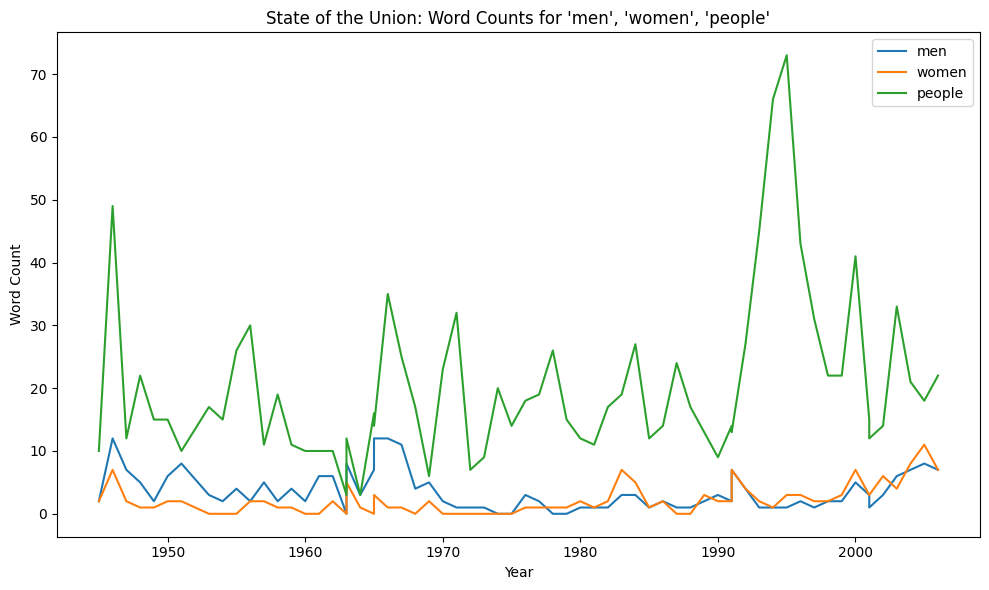


8. Initial letter frequency by gender (first 5 letters):
8. female.txt:  {'a': 443, 'b': 246, 'c': 469, 'd': 308, 'e': 251}
8. male.txt:  {'a': 213, 'b': 173, 'c': 166, 'd': 146, 'e': 119}

11. Modal verb distribution by genre:
11. adventure:  {'can': 48, 'could': 154, 'may': 7, 'might': 59, 'must': 27, 'will': 51}
11. belles_lettres:  {'can': 249, 'could': 216, 'may': 221, 'might': 113, 'must': 171, 'will': 246}
11. editorial:  {'can': 124, 'could': 57, 'may': 79, 'might': 39, 'must': 55, 'will': 235}
11. fiction:  {'can': 39, 'could': 168, 'may': 10, 'might': 44, 'must': 55, 'will': 56}
11. government:  {'can': 119, 'could': 38, 'may': 179, 'might': 13, 'must': 102, 'will': 244}
11. hobbies:  {'can': 276, 'could': 59, 'may': 143, 'might': 22, 'must': 84, 'will': 269}
11. humor:  {'can': 17, 'could': 33, 'may': 8, 'might': 8, 'must': 9, 'will': 13}
11. learned:  {'can': 367, 'could': 159, 'may': 336, 'might': 128, 'must': 203, 'will': 340}
11. lore:  {'can': 170, 'could': 142, 'may':

In [ ]:
# # 1. Create a variable phrase containing a list of words. Review list operations.
# phrase = ['I', 'love', 'natural', 'language', 'processing']
# print("1. phrase:", phrase)
# print("1. Addition:", phrase + ['with', 'Python'])
# print("1. Multiplication:", phrase * 2)
# print("1. Indexing:", phrase[2])
# print("1. Slicing:", phrase[1:4])
# print("1. Sorting:", sorted(phrase))

# # 2. Explore austen-persuasion.txt: tokens and types
# persuasion_words = gutenberg.words('austen-persuasion.txt')
# persuasion_tokens = len(persuasion_words)
# persuasion_types = len(set([w.lower() for w in persuasion_words if w.isalpha()]))
# print("\n2. Austen Persuasion - tokens:", persuasion_tokens)
# print("2. Austen Persuasion - types:", persuasion_types)

# # 3. Brown and Webtext corpus: sample text in two genres
# print("\n3. Brown genres:", brown.categories())
# news_words = brown.words(categories='news')[:20]
# romance_words = brown.words(categories='romance')[:20]
# print("3. Sample from Brown 'news':", news_words)
# print("3. Sample from Brown 'romance':", romance_words)
# print("3. Webtext fileids:", webtext.fileids())
# print("3. Sample from Webtext 'grail.txt':", webtext.words('grail.txt')[:20])
# print("3. Sample from Webtext 'firefox.txt':", webtext.words('firefox.txt')[:20])

# 4. State of the Union: count 'men', 'women', 'people' in each document
# Read in the texts of the State of the Union addresses, using the state_union corpus reader.
# Count occurrences of men, women, and people in each document.
# What has happened to the usage of these words over time?
import matplotlib.pyplot as plt

print("\n4. State of the Union word counts for 'men', 'women', 'people':")
years = []
men_counts = []
women_counts = []
people_counts = []

for fileid in state_union.fileids():
    year = int(fileid[:4])
    words = [w.lower() for w in state_union.words(fileid)]
    men = words.count('men')
    women = words.count('women')
    people = words.count('people')
    years.append(year)
    men_counts.append(men)
    women_counts.append(women)
    people_counts.append(people)
    # print(f"4. {fileid}: men={men}, women={women}, people={people}")

# Plotting the counts over time
plt.figure(figsize=(10,6))
plt.plot(years, men_counts, label='men')
plt.plot(years, women_counts, label='women')
plt.plot(years, people_counts, label='people')
plt.xlabel('Year')
plt.ylabel('Word Count')
plt.title("State of the Union: Word Counts for 'men', 'women', 'people'")
plt.legend()
plt.tight_layout()
plt.show()

# # 5. Holonym-meronym relations for some nouns
# nouns = ['tree', 'car', 'water']
# for noun in nouns:
#     synsets = wn.synsets(noun, pos='n')
#     if synsets:
#         s = synsets[0]
#         print(f"\n5. Noun: {noun}")
#         print("  5. member_meronyms:", s.member_meronyms())
#         print("  5. part_meronyms:", s.part_meronyms())
#         print("  5. substance_meronyms:", s.substance_meronyms())
#         print("  5. member_holonyms:", s.member_holonyms())
#         print("  5. part_holonyms:", s.part_holonyms())
#         print("  5. substance_holonyms:", s.substance_holonyms())

# # 6. Comparative wordlists: translate object problem
# print("\n6. Comparative wordlists problem:")
# print("6. If a German or Spanish word is ambiguous (maps to multiple English words), or if two words in different languages map to the same English word, the translate object will lose information or be ambiguous. To avoid this, use a structure that maps (language, word) pairs to English, or use a nested dictionary.")

# # 7. Concordance for 'however'
# print("\n7. Concordance for 'however' in Austen Persuasion:")
# text = nltk.Text([w.lower() for w in persuasion_words])
# text.concordance('however', width=80, lines=5)

# 8. Conditional frequency distribution over Names corpus
# Define a conditional frequency distribution over the Names corpus that allows
# you to see which initialletters are more frequent for males vs. females (cf. 4.4).

cfd = ConditionalFreqDist(
    (gender, name[0].lower())
    for gender in names.fileids()
    for name in names.words(gender)
)
print("\n8. Initial letter frequency by gender (first 5 letters):")
for gender in names.fileids():
    print(f"8. {gender}: ", dict(list(cfd[gender].items())[:5]))

# # 9. Compare two texts: Moby Dick and Sense and Sensibility
# moby = nltk.Text(gutenberg.words('melville-moby_dick.txt'))
# sense = nltk.Text(gutenberg.words('austen-sense.txt'))
# moby_vocab = set([w.lower() for w in moby if w.isalpha()])
# sense_vocab = set([w.lower() for w in sense if w.isalpha()])
# print("\n9. Moby Dick vocab size:", len(moby_vocab))
# print("9. Sense and Sensibility vocab size:", len(sense_vocab))
# print("9. Vocabulary richness (tokens/types):")
# print("  9. Moby Dick:", len(moby) / len(moby_vocab))
# print("  9. Sense and Sensibility:", len(sense) / len(sense_vocab))
# print("9. monstrous in Moby Dick:", moby.concordance('monstrous', lines=3))
# print("9. monstrous in Sense and Sensibility:", sense.concordance('monstrous', lines=3))

# # 10. Top word types accounting for a third of all tokens
# def top_types_for_fraction(text, fraction=1/3):
#     words = [w.lower() for w in text if w.isalpha()]
#     total = len(words)
#     fdist = FreqDist(words)
#     running = 0
#     types = 0
#     for word, count in fdist.most_common():
#         running += count
#         types += 1
#         if running >= total * fraction:
#             break
#     return types, total

# print("\n10. Top word types for 1/3 of tokens in Brown news:")
# types, total = top_types_for_fraction(brown.words(categories='news'))
# print(f"10. {types} types account for 1/3 of {total} tokens.")

# 11. Modal distributions by genre
# Investigate the table of modal distributions and look for other patterns. 
# Try to explain them in terms of your own impressionistic understanding of the different genres.
# Can you find other closed classes of words that exhibit significant differences across different genres?

modals = ['can', 'could', 'may', 'might', 'must', 'will']
cfd_modals = ConditionalFreqDist(
    (genre, word.lower())
    for genre in brown.categories()
    for word in brown.words(categories=genre)
    if word.lower() in modals
)
print("\n11. Modal verb distribution by genre:")
for genre in brown.categories():
    print(f"11. {genre}: ", {m: cfd_modals[genre][m] for m in modals})

# # 12. CMU Pronouncing Dictionary: distinct words and multiple pronunciations
# entries = cmudict.entries()
# words = [word for word, pron in entries]
# word_pron_count = Counter(words)
# distinct_words = len(word_pron_count)
# multi_pron = sum(1 for w, c in word_pron_count.items() if c > 1)
# print(f"\n12. CMUdict: {distinct_words} distinct words, {multi_pron} have >1 pronunciation ({multi_pron/distinct_words:.2%})")

# # 13. Percentage of noun synsets with no hyponyms
# noun_synsets = list(wn.all_synsets('n'))
# no_hyponyms = sum(1 for s in noun_synsets if not list(s.hyponyms()))
# percent_no_hyponyms = 100 * no_hyponyms / len(noun_synsets)
# print(f"\n13. {percent_no_hyponyms:.2f}% of noun synsets have no hyponyms.")

# # 14. supergloss(s): definition + hypernyms + hyponyms
# def supergloss(s):
#     gloss = s.definition()
#     gloss += ' | Hypernyms: ' + ' ; '.join(h.definition() for h in s.hypernyms())
#     gloss += ' | Hyponyms: ' + ' ; '.join(h.definition() for h in s.hyponyms())
#     return gloss

# print("\n14. Supergloss for 'dog.n.01':")
# print("14.", supergloss(wn.synset('dog.n.01')))

# 15. Words that occur at least three times in Brown
brown_words_lower = [w.lower() for w in brown.words() if w.isalpha()]
fdist_brown = FreqDist(brown_words_lower)
words_3plus = [w for w, c in fdist_brown.items() if c >= 3]
print(f"\n15. Number of words in Brown corpus occurring at least 3 times: {len(words_3plus)}")

# 16. Table of lexical diversity scores for Brown genres
print("\n16. Lexical diversity (tokens/types) by Brown genre:")
diversity = {}
for genre in brown.categories():
    words = [w.lower() for w in brown.words(categories=genre) if w.isalpha()]
    tokens = len(words)
    types = len(set(words))
    ratio = tokens / types if types else 0
    diversity[genre] = ratio
    print(f"16. {genre}: {ratio:.2f}")
lowest = min(diversity, key=diversity.get)
print(f"16. Lowest diversity (most types per token): {lowest}")

# 17. 50 most frequent non-stopwords in a text
def most_frequent_nonstopwords(text, n=50):
    stop_words = set(stopwords.words('english'))
    words = [w.lower() for w in text if w.isalpha()]
    filtered_words = [w for w in words if w not in stop_words]
    freq_dist = Counter(filtered_words)
    return freq_dist.most_common(n)

print("\n17. 50 most frequent non-stopwords in Brown news:")
top50 = most_frequent_nonstopwords(brown.words(categories='news'), 50)
print("17.", top50)

# 18. 50 most frequent bigrams (excluding stopwords)
def most_frequent_nonstopword_bigrams(text, n=50):
    stop_words = set(stopwords.words('english'))
    words = [w.lower() for w in text if w.isalpha()]
    bigram_list = [
        (w1, w2) for w1, w2 in bigrams(words)
        if w1 not in stop_words and w2 not in stop_words
    ]
    freq_dist = Counter(bigram_list)
    return freq_dist.most_common(n)

print("\n18. 50 most frequent bigrams (no stopwords) in Brown news:")
top50_bigrams = most_frequent_nonstopword_bigrams(brown.words(categories='news'), 50)
print("18.", top50_bigrams)

# # 19. Table of word frequencies by genre
# def word_freq_by_genre(wordlist, genres):
#     cfd = ConditionalFreqDist(
#         (genre, word.lower())
#         for genre in genres
#         for word in brown.words(categories=genre)
#         if word.lower() in wordlist
#     )
#     print(f"\n19. {'Genre':<12}", end='')
#     for word in wordlist:
#         print(f"{word:<10}", end='')
#     print()
#     for genre in genres:
#         print(f"19. {genre:<12}", end='')
#         for word in wordlist:
#             print(f"{cfd[genre][word]:<10}", end='')
#         print()

# word_freq_by_genre(['can', 'could', 'may', 'might', 'must', 'will'], brown.categories())
